## Student Marks Prediction (Case Study)

You are given some information about students like:

- the number of courses they have opted for
- the average time studied per day by students
- marks obtained by students

Gerekli kütüphaneleri import edelim 

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### EDA 

In [2]:
df=pd.read_csv('Student_Marks.csv')

In [4]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.describe()

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


In [7]:
df.corr()

,number_courses,time_study,Marks
number_courses,1.000000,0.204844,0.417335
time_study,0.204844,1.000000,0.942254
Marks,0.417335,0.942254,1.000000


In [8]:
df.isnull().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

In [15]:
#!pip install ydata-profiling


### Otomatik Veri Analizi

In [14]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Regresyon Veri Analizi")
profile.to_file("report.html")



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 12360.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML raporumu kodumda Iframe ile gösteriyorum 

In [16]:
from ydata_profiling import ProfileReport
from IPython.display import IFrame

profile = ProfileReport(df, title="Regresyon Veri Analizi")

profile.to_file("report.html")

IFrame(src="report.html", width="100%", height=800)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 1427.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

regresyon modeli için x ve y değişkenlerini tanımlıyoruz


In [23]:
x = df.drop('Marks', axis=1)
y = df['Marks']


In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

şimdi regresyon modelini tanımlıyıp fit and predict yapıcağız

In [28]:
model=LinearRegression()

In [29]:
model.fit(x_train,y_train)

LinearRegression()

In [30]:
model.score(x_test,y_test)

0.9459936100591214

In [32]:
y_pred = model.predict(x_test)


In [33]:
from sklearn.metrics import mean_squared_error, r2_score


In [34]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [35]:

print("MSE:", mse)
print("R²:", r2)

MSE: 14.20072613637453
R²: 0.9459936100591214


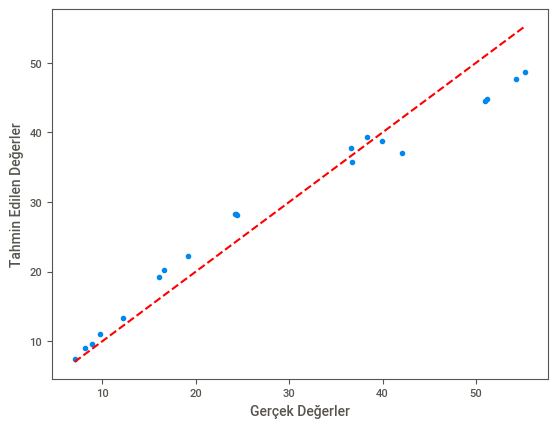

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()


In [38]:
import joblib

joblib.dump(model, "regression_model_student_marks.joblib")


['regression_model_student_marks.joblib']

In [41]:
import sklearn
print(sklearn.__version__)


1.6.1


Summary
So this is how you can solve the problem of student marks prediction with machine learning

https://amanxai.com/2022/04/26/student-marks-prediction-with-machine-learning/